In [2]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path='Visadataset.csv'
visa_df=pd.read_csv(path)
visa_df

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [3]:
# we have two columns 
# continent and another columns is case_status
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [4]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [ ]:
# how many asia students got certified
# how many asia students got denied 

# idea
# con1=visa_df['continent']=='Asia'
# con2=shortlist certified
# con=con1&con2
# extract the data len

In [5]:
continent_labels=visa_df['continent'].unique()
certified_list=[]
for i in continent_labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con=con1&con2
    certified_list.append(len(visa_df[con]))
certified_list

[11012, 397, 2037, 2957, 493, 122]

In [6]:
continent_labels=visa_df['continent'].unique()
certified_list=[]
denied_list=[]
for i in continent_labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    certi_con=con1&con2
    deni_con=con1&con3
    certified_list.append(len(visa_df[certi_con]))
    denied_list.append(len(visa_df[deni_con]))
certified_list,denied_list
pd.DataFrame(zip(certified_list,denied_list),index=continent_labels,
             columns=['Certified','Denied'])

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


In [7]:
con=visa_df['case_status']=='Certified'
visa_df[con].groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [8]:
col1=visa_df['continent']
col2=visa_df['case_status']
pd.crosstab(col1,col2)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [9]:
col2=visa_df['continent']
col1=visa_df['case_status']
pd.crosstab(col1,col2)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [10]:
col1=visa_df['continent']
col2=visa_df['case_status']
r1=pd.crosstab(col1,col2)

In [11]:
col2=visa_df['continent']
col1=visa_df['case_status']
r2=pd.crosstab(col1,col2)

<Axes: xlabel='continent'>

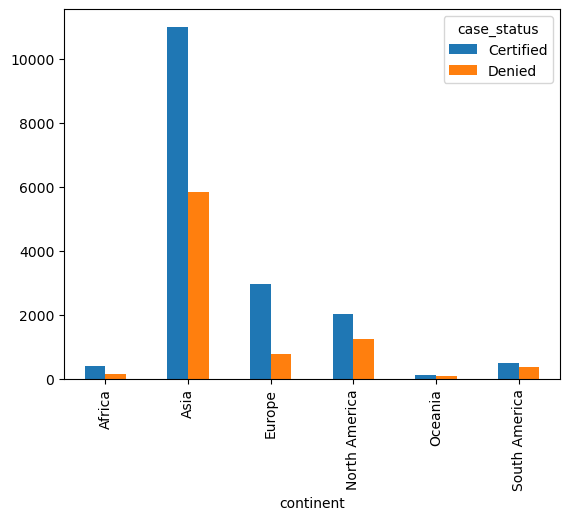

In [12]:
r1.plot(kind='bar')

<Axes: xlabel='case_status'>

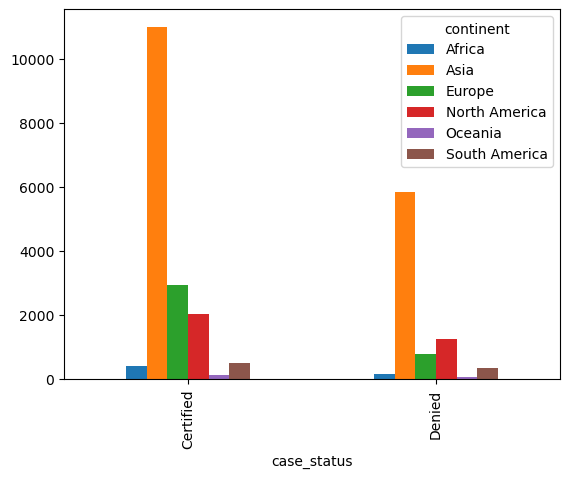

In [31]:
r2.plot(kind='bar')

In [35]:
# continent
# eductaion of employee
# case_status
# 
# there are 11k applicants certified from Asia 
#   Now i want to know these 11k based on education 

In [13]:
ol1=visa_df['continent']
col2=visa_df['education_of_employee']
col3=visa_df['case_status']
cols=[col2,col3]
r3=pd.crosstab(col1,cols)
r3

education_of_employee Bachelor's        Doctorate        High School         \
case_status            Certified Denied Certified Denied   Certified Denied   
case_status                                                                   
Certified                   6367      0      1912      0        1164      0   
Denied                         0   3867         0    280           0   2256   

education_of_employee  Master's         
case_status           Certified Denied  
case_status                             
Certified                  7575      0  
Denied                        0   2059

In [14]:
ol1=visa_df['continent']
col2=visa_df['education_of_employee']
col3=visa_df['case_status']
cols=[col1,col2]
r3=pd.crosstab(col1,cols)
r3

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                   6367      1912        1164     7575          0   
Denied                         0         0           0        0       3867   

case_status                                           
education_of_employee Doctorate High School Master's  
case_status                                           
Certified                     0           0        0  
Denied                      280        2256     2059

In [38]:
ol1=visa_df['continent']
col2=visa_df['education_of_employee']
col3=visa_df['case_status']
cols=[col1,col3]
r3=pd.crosstab(col1,cols)
r3

continent        Africa             Asia           Europe         \
case_status   Certified Denied Certified Denied Certified Denied   
continent                                                          
Africa              397    154         0      0         0      0   
Asia                  0      0     11012   5849         0      0   
Europe                0      0         0      0      2957    775   
North America         0      0         0      0         0      0   
Oceania               0      0         0      0         0      0   
South America         0      0         0      0         0      0   

continent     North America          Oceania        South America         
case_status       Certified Denied Certified Denied     Certified Denied  
continent                                                                 
Africa                    0      0         0      0             0      0  
Asia                      0      0         0      0             0      0  
Europe                    0      0         0      0             0      0  
North America          2037   1255         0      0             0      0  
Oceania                   0      0       122     70             0      0  
South America             0      0         0      0           493    359

**Numerical-Numerical**

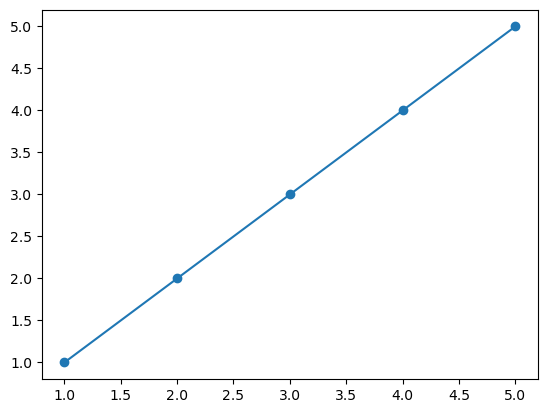

In [17]:
x=[1,2,3,4,5]
y=[1,2,3,4,5]
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

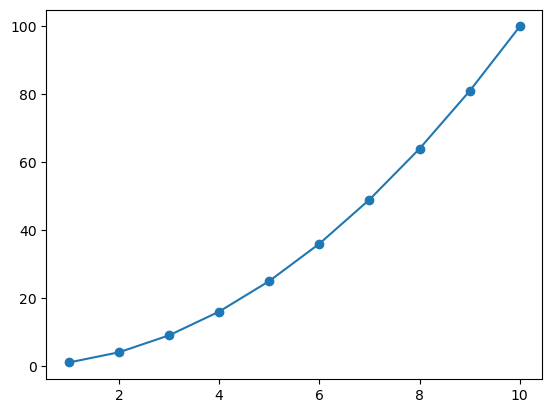

In [18]:
#x=[i for i in range(1,10)]
x=list(range(1,11))
y=[i**2 for i in x]
plt.scatter(x,y)
plt.plot(x,y)

In [19]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

Text(0, 0.5, 'prevailing_wage')

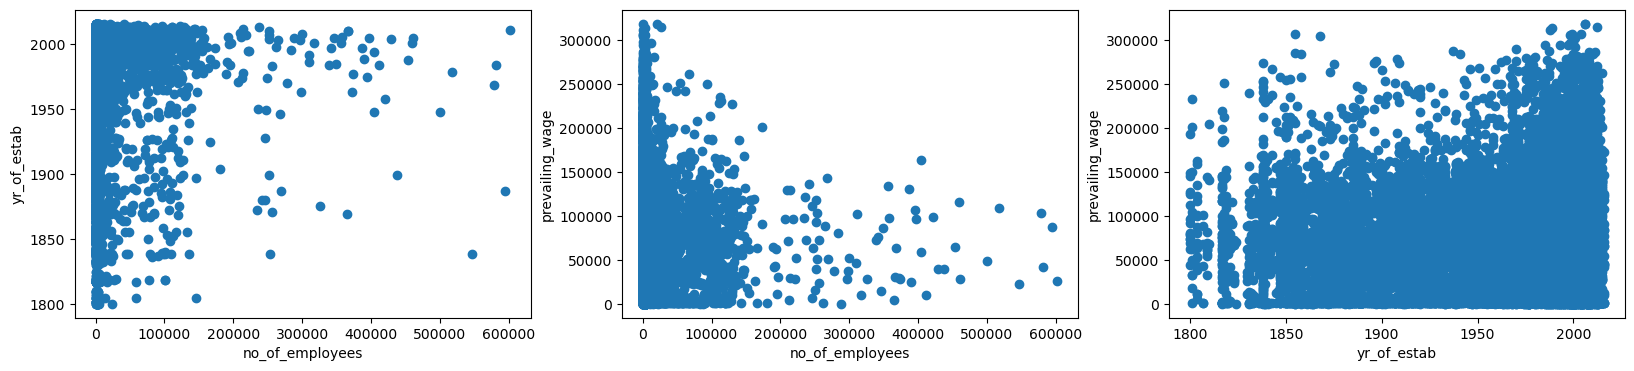

In [22]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(20,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.xlabel('no_of_employees')
plt.ylabel('yr_of_estab')
#=====================================================
plt.subplot(1,3,2).scatter(col1,col3)
plt.xlabel('no_of_employees')
plt.ylabel('prevailing_wage')
#=====================================================
plt.subplot(1,3,3).scatter(col2,col3)
plt.xlabel('yr_of_estab')
plt.ylabel('prevailing_wage')

**Correaltion**

In [23]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


**Heat map**

<Axes: >

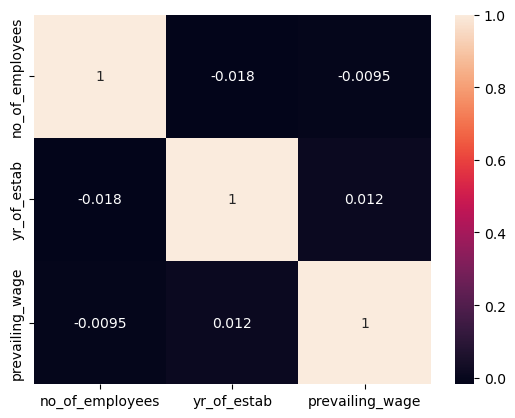

In [26]:
import seaborn as sns 
corr=visa_df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
# to get the values we nee dto use the annototion 

In [45]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path1='winequality_red.csv'
wine_df=pd.read_csv(path1)
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<Axes: >

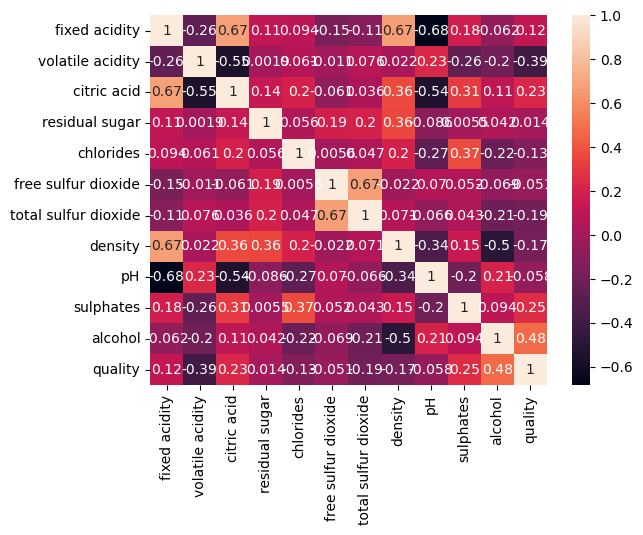

In [46]:
import seaborn as sns 
corr=wine_df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)